# 🔤 Notebook 2: OCR Recognizer Fine-Tuning (TrOCR)
## Indonesian ALPR Pipeline — Stage 3: Plate Text Recognition

---

### 📋 Deskripsi
Notebook ini merupakan **tahap ketiga** dari pipeline ALPR Indonesia — fine-tuning model OCR untuk **membaca teks dari crop gambar plat nomor**.

**Pertanyaan yang dijawab model ini:**
> *"Dari gambar crop plat ini, tulisannya apa?"*

### 🗂️ Dataset yang Digunakan
| Dataset | Jumlah Gambar | Format Label | Keterangan |
|:--------|:-------------:|:------------:|:-----------|
| `plate_text_dataset` | 1.863 | CSV (`filename,label`) | Crop plat + teks langsung |
| `Indonesian License Plate Recognition Dataset` | 1.906 | YOLO char-level | Crop plat + bbox per karakter |
| **Total** | **~3.769** | **(image, text) pairs** | Setelah rekonstruksi teks dari YOLO |

### 🔬 Rancangan Eksperimen
| Eksperimen | Base Model | Preprocessing | Strategi Training | Target |
|:-----------|:-----------|:-------------:|:-----------------:|:------:|
| Exp-A | `trocr-small-printed` | Minimal | Direct fine-tune | Baseline cepat |
| Exp-B | `trocr-base-printed` | Minimal | Direct fine-tune | Baseline akurasi |
| **Exp-C** | **`trocr-base-printed`** | **Enhanced (CLAHE+Bilateral)** | **Direct fine-tune** | **Recommended** |
| Exp-D | `trocr-base-printed` | Enhanced | Synth → Real (2-stage) | Research/Advanced |

### 📊 Metrik Evaluasi
- **CER** (Character Error Rate) — metrik utama
- **Exact Match Accuracy** — seberapa sering prediksi 100% benar
- **Levenshtein Distance** — jarak edit rata-rata

### ⚙️ Environment
- **Platform**: Kaggle Notebooks
- **GPU**: NVIDIA Tesla T4 × 2
- **Framework**: Hugging Face Transformers + PyTorch

### 📤 Output Notebook Ini
- `best_ocr_{exp_id}/` — folder checkpoint TrOCR terbaik per eksperimen
- `ocr_experiment_comparison.csv` — tabel perbandingan metrik
- Grafik training loss, CER per epoch, confusion matrix karakter


---
## 🔧 Bagian 0: Verifikasi GPU & Environment


In [1]:
# ============================================================
# Cell 0.1 — Download Dataset ANPR.zip dari Google Drive & Unzip
# ============================================================
# File ANPR.zip berisi dua folder utama:
#   1. Indonesian Plate Dataset/
#   2. Indonesian Vehicle Liscense Plate Dataset/
#
# PANDUAN PENGGUNAAN:
# 1. Upload file ANPR.zip ke Google Drive Anda.
# 2. Share file: Anyone with the link (Viewer).
# 3. Salin file ID dari link Drive (antara /d/ dan /view):
#    Contoh: https://drive.google.com/file/d/1aFSf47bcI-5spmxrpZgW2poUf2MbKf0i/view
#    Maka GDRIVE_FILE_ID = "1aFSf47bcI-5spmxrpZgW2poUf2MbKf0i"

GDRIVE_FILE_ID = "12_V2N723jaXhnBhmL_v5IgnYKsvHETLT"

import os
from pathlib import Path

WORKING_DIR = Path("/kaggle/working")
ZIP_PATH    = WORKING_DIR / "ANPR.zip"
EXTRACT_DIR = WORKING_DIR / "ANPR"

# Cek apakah dataset sudah tersedia
already_extracted = EXTRACT_DIR.exists() and any(EXTRACT_DIR.iterdir())

if not already_extracted:
    if GDRIVE_FILE_ID != "YOUR_GDRIVE_FILE_ID_HERE":
        print("=" * 60)
        print("🚀 PROSES DOWNLOAD & EXTRAKSI DATASET ANPR.zip")
        print("=" * 60)
        
        # 1. Install gdown
        !pip install gdown -q
        import gdown
        
        # 2. Download zip dari Google Drive
        if not ZIP_PATH.exists():
            print(f"⬇️ Mengunduh ANPR.zip dari Google Drive (ID: {GDRIVE_FILE_ID})...")
            download_url = f"https://drive.google.com/uc?id={GDRIVE_FILE_ID}"
            gdown.download(download_url, str(ZIP_PATH), quiet=False)
        
        # 3. Unzip ke /kaggle/working/ANPR
        if ZIP_PATH.exists() and ZIP_PATH.stat().st_size > 1000:
            print(f"📦 Mengekstrak ANPR.zip ke {EXTRACT_DIR} ...")
            EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
            !unzip -q "{ZIP_PATH}" -d "{EXTRACT_DIR}"
            
            # 4. Hapus zip sementara untuk menghemat kuota disk Kaggle
            try:
                ZIP_PATH.unlink()
                print("🧹 File ANPR.zip sementara dihapus untuk menghemat ruang disk.")
            except Exception as e:
                print(f"⚠️ Gagal menghapus zip sementara: {e}")
            print("✅ Ekstraksi selesai! Folder ANPR siap digunakan.")
        else:
            print("⚠️ File ANPR.zip tidak ditemukan atau ukuran tidak valid.")
            print("   Pastikan file ID Drive benar dan share link diset 'Anyone with the link'!")
    else:
        print("ℹ️ GDRIVE_FILE_ID masih bernilai default ('YOUR_GDRIVE_FILE_ID_HERE').")
        print("   Lewati cell ini jika dataset sudah di-attach via /kaggle/input/ atau lokal.")
else:
    print(f"✅ Dataset ANPR sudah tersedia di: {EXTRACT_DIR}")


🚀 PROSES DOWNLOAD & EXTRAKSI DATASET ANPR.zip
⬇️ Mengunduh ANPR.zip dari Google Drive (ID: 12_V2N723jaXhnBhmL_v5IgnYKsvHETLT)...


Downloading...
From (original): https://drive.google.com/uc?id=12_V2N723jaXhnBhmL_v5IgnYKsvHETLT
From (redirected): https://drive.google.com/uc?id=12_V2N723jaXhnBhmL_v5IgnYKsvHETLT&confirm=t&uuid=4f5d2e96-8bac-4f19-a79a-e68787fd7a52
To: /kaggle/working/ANPR.zip
100%|██████████| 3.52G/3.52G [00:36<00:00, 96.1MB/s]


📦 Mengekstrak ANPR.zip ke /kaggle/working/ANPR ...
🧹 File ANPR.zip sementara dihapus untuk menghemat ruang disk.
✅ Ekstraksi selesai! Folder ANPR siap digunakan.


In [2]:
# ============================================================
# Cell 0.1 — Verifikasi GPU Kaggle T4x2
# ============================================================
import torch
import os
import multiprocessing

print("=" * 60)
print("GPU & CUDA ENVIRONMENT VERIFICATION")
print("=" * 60)
print(f"PyTorch Version    : {torch.__version__}")
print(f"CUDA Available     : {torch.cuda.is_available()}")
print(f"CUDA Version       : {torch.version.cuda}")
print(f"Number of GPU(s)   : {torch.cuda.device_count()}")

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"  GPU [{i}] Name    : {props.name}")
    print(f"  GPU [{i}] VRAM    : {props.total_memory / 1024**3:.1f} GB")

# Untuk Hugging Face Trainer: gunakan semua GPU yang tersedia
N_GPU = torch.cuda.device_count()
NUM_WORKERS = min(4, multiprocessing.cpu_count())
print(f"\nN_GPU              : {N_GPU}")
print(f"Num Workers        : {NUM_WORKERS}")
print("=" * 60)
print("✅ Environment verified.")


GPU & CUDA ENVIRONMENT VERIFICATION
PyTorch Version    : 2.10.0+cu128
CUDA Available     : True
CUDA Version       : 12.8
Number of GPU(s)   : 2
  GPU [0] Name    : Tesla T4
  GPU [0] VRAM    : 14.6 GB
  GPU [1] Name    : Tesla T4
  GPU [1] VRAM    : 14.6 GB

N_GPU              : 2
Num Workers        : 4
✅ Environment verified.


In [3]:
# ============================================================
# Cell 0.2 — Install Library
# ============================================================
# Transformers (TrOCR), evaluate (CER/WER), sentencepiece
!pip install transformers>=4.35.0 -q
!pip install evaluate jiwer datasets -q
!pip install sentencepiece -q
!pip install Pillow opencv-python-headless -q

import transformers
import evaluate
print(f"Transformers version : {transformers.__version__}")
print(f"Evaluate version     : {evaluate.__version__}")
print("✅ Library installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 86.5 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 44.4 MB/s eta 0:00:0000:0100:01
Transformers version : 5.0.0
Evaluate version     : 0.4.6
✅ Library installed.


---
## 📦 Bagian 1: Konfigurasi Path & Konstanta


In [4]:
# ============================================================
# Cell 1.1 — Konfigurasi Path Dataset (Smart Path Discovery)
# ============================================================
# Sistem otomatis mencari subfolder dataset baik dari hasil unzip Drive
# (/kaggle/working/ANPR) maupun dari Kaggle Input (/kaggle/input/...) atau lokal.
#
# Subfolder yang dibutuhkan untuk TrOCR Recognizer:
#   1. plate_text_dataset (label.csv & dataset/ crop plat)
#   2. Indonesian License Plate Recognition Dataset (classes.names & images/ & labels/)

import os
from pathlib import Path

KAGGLE_INPUT   = Path("/kaggle/input")
KAGGLE_WORKING = Path("/kaggle/working")

SEARCH_ROOTS = [
    KAGGLE_WORKING / "ANPR",
    KAGGLE_WORKING,
    KAGGLE_INPUT / "anpr",
    KAGGLE_INPUT,
    Path("d:/Deteksi Plat"),
]

def find_ocr_dataset_paths(roots):
    text_root = None
    text_csv = None
    text_imgs = None
    rec_root = None
    rec_classes = None
    
    for r in roots:
        if not r.exists():
            continue
            
        # 1. Cari label.csv & dataset/ gambar crop
        if text_csv is None:
            for p in r.rglob("label.csv"):
                text_csv = p
                text_root = p.parent
                cand_img = p.parent / "dataset"
                if cand_img.exists():
                    text_imgs = cand_img
                break
                
        # 2. Cari Recognition Dataset (classes.names & labels)
        if rec_classes is None:
            for p in r.rglob("classes.names"):
                if "Recognition" in str(p.parent) or (p.parent / "labels").exists():
                    rec_classes = p
                    rec_root = p.parent
                    break
                    
        if text_csv is not None and text_imgs is not None and rec_root is not None and rec_classes is not None:
            break
            
    return text_root, text_csv, text_imgs, rec_root, rec_classes

DS_TEXT_ROOT, DS_TEXT_CSV, DS_TEXT_IMGS, DS_REC_ROOT, DS_REC_CLASSES = find_ocr_dataset_paths(SEARCH_ROOTS)

# Output directory
WORK_DIR = KAGGLE_WORKING / "ocr_plate_recognizer"
WORK_DIR.mkdir(parents=True, exist_ok=True)

print(f"Work Directory  : {WORK_DIR}")
print()
print("=" * 65)
print("Dataset Path Verification (TrOCR Recognizer)")
print("=" * 65)
items = [
    (DS_TEXT_ROOT,   "DS1 Root (plate_text_dataset)"),
    (DS_TEXT_CSV,    "DS1 Label CSV (label.csv)"),
    (DS_TEXT_IMGS,   "DS1 Crop Images (dataset/)"),
    (DS_REC_ROOT,    "DS2 Root (Recognition Dataset)"),
    (DS_REC_CLASSES, "DS2 Classes (classes.names)"),
]

all_found = True
for path, label in items:
    found = path is not None and path.exists()
    status = "✅" if found else "❌ NOT FOUND"
    print(f"{status} {label:<40}: {path if found else 'Tidak ditemukan'}")
    if not found:
        all_found = False

print("=" * 65)
if all_found:
    print("🎉 Seluruh komponen dataset OCR berhasil ditemukan & tersinkronisasi!")
else:
    print("⚠️ Ada komponen yang belum ditemukan. Periksa apakah ANPR.zip sudah diekstrak.")


Work Directory  : /kaggle/working/ocr_plate_recognizer

Dataset Path Verification (TrOCR Recognizer)
✅ DS1 Root (plate_text_dataset)           : /kaggle/working/ANPR/Indonesian Vehicle Liscense Plate Dataset/plate_text_dataset/plate_text_dataset
✅ DS1 Label CSV (label.csv)               : /kaggle/working/ANPR/Indonesian Vehicle Liscense Plate Dataset/plate_text_dataset/plate_text_dataset/label.csv
✅ DS1 Crop Images (dataset/)              : /kaggle/working/ANPR/Indonesian Vehicle Liscense Plate Dataset/plate_text_dataset/plate_text_dataset/dataset
✅ DS2 Root (Recognition Dataset)          : /kaggle/working/ANPR/Indonesian Plate Dataset/Indonesian License Plate Recognition Dataset
✅ DS2 Classes (classes.names)             : /kaggle/working/ANPR/Indonesian Plate Dataset/Indonesian License Plate Recognition Dataset/classes.names
🎉 Seluruh komponen dataset OCR berhasil ditemukan & tersinkronisasi!


In [5]:
# ============================================================
# Cell 1.2 — Konstanta Global
# ============================================================
import random
import numpy as np

# ─── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ─── Split Ratio (konsisten dengan SPLIT_DETECTION.md) ─────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.20
TEST_RATIO  = 0.10

# ─── Image Config untuk TrOCR ──────────────────────────────────────────────────
# TrOCR secara default menggunakan gambar 384x384,
# tapi untuk plat nomor landscape kita resize ke 384x128
IMG_WIDTH  = 384
IMG_HEIGHT = 128

# ─── Training Config ───────────────────────────────────────────────────────────
MAX_TARGET_LENGTH = 12   # Plat Indonesia max ~9 karakter + spasi/padding
BATCH_SIZE        = 16   # Per GPU; effective = 16 * 2 GPU = 32 (T4x2)
EPOCHS_BASELINE   = 20
EPOCHS_FULL       = 50
PATIENCE          = 8    # Early stopping
LR_BASELINE       = 5e-5
LR_FULL           = 1e-4

# ─── Karakter yang valid di plat Indonesia ─────────────────────────────────────
# Format TNKB: [A-Z]{1,2} [0-9]{1,4} [A-Z]{1,3}
# Karakter yang sering ambigu: O vs 0, B vs 8, I vs 1
VALID_CHARS = set('ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')

print("=" * 55)
print("GLOBAL CONSTANTS CONFIGURED")
print("=" * 55)
print(f"Split Ratio     : Train={TRAIN_RATIO} | Val={VAL_RATIO} | Test={TEST_RATIO}")
print(f"Image Size      : {IMG_WIDTH}x{IMG_HEIGHT}px (landscape untuk plat)")
print(f"Max Token Length: {MAX_TARGET_LENGTH}")
print(f"Batch Size      : {BATCH_SIZE} per GPU → Effective: {BATCH_SIZE * N_GPU}")
print(f"Valid Chars     : {len(VALID_CHARS)} karakter ({sorted(VALID_CHARS)[:10]}...+)")


GLOBAL CONSTANTS CONFIGURED
Split Ratio     : Train=0.7 | Val=0.2 | Test=0.1
Image Size      : 384x128px (landscape untuk plat)
Max Token Length: 12
Batch Size      : 16 per GPU → Effective: 32
Valid Chars     : 36 karakter (['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...+)


---
## 📊 Bagian 2: Persiapan Dataset

### Alur Rekonstruksi Label:
```
Dataset 1 (plate_text_dataset)
  label.csv: 'AA4795BE.jpg' → 'AA4795BE'   ─────────────────────────┐
                                                                      ├→ MERGED (image_path, text) pairs
Dataset 2 (Recognition Dataset)
  YOLO char labels: class_id + bbox per karakter                     │
  → sort bbox by x_center → reconstruct text: 'G0589EJ' ────────────┘
```


In [6]:
# ============================================================
# Cell 2.1 — Load Kamus Karakter dari classes.names
# ============================================================

def load_class_names(classes_path):
    """
    Baca file classes.names dan kembalikan list karakter.
    Index 0-9  → '0'-'9'
    Index 10-35 → 'A'-'Z'
    """
    with open(classes_path, 'r') as f:
        classes = [line.strip() for line in f if line.strip()]
    return classes


CLASS_NAMES_CHARS = load_class_names(DS_REC_CLASSES)
print(f"Total kelas karakter : {len(CLASS_NAMES_CHARS)}")
print(f"Karakter index 0-9   : {CLASS_NAMES_CHARS[:10]}")
print(f"Karakter index 10-15 : {CLASS_NAMES_CHARS[10:16]}")
print(f"Karakter index 35    : {CLASS_NAMES_CHARS[35]}")


Total kelas karakter : 36
Karakter index 0-9   : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Karakter index 10-15 : ['A', 'B', 'C', 'D', 'E', 'F']
Karakter index 35    : Z


In [7]:
# ============================================================
# Cell 2.2 — Fungsi Rekonstruksi Teks dari YOLO Char Labels
# ============================================================

def reconstruct_text_from_yolo_label(label_path, class_names):
    """
    Rekonstruksi teks plat nomor dari anotasi YOLO per-karakter.

    Cara kerja:
    1. Baca semua baris: class_id, x_center, y_center, w, h
    2. Sort berdasarkan x_center (kiri → kanan)
    3. Convert class_id → karakter via class_names

    Contoh:
        Input  : [16 0.11 ...], [9 0.31 ...], [0 0.41 ...], ...
        Sorted : 16(G) → 9(9) → 0(0) → ...
        Output : 'G90589EJ'
    """
    char_boxes = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id  = int(parts[0])
            x_center = float(parts[1])
            char_boxes.append((x_center, cls_id))

    # Sort by x_center (posisi horizontal kiri ke kanan)
    char_boxes.sort(key=lambda x: x[0])

    # Rekonstruksi string
    text = ''.join(class_names[cls_id] for _, cls_id in char_boxes)
    return text


# Verifikasi dengan sample label
print("=" * 55)
print("Verifikasi Rekonstruksi Teks")
print("=" * 55)
for split in ["train", "val", "test"]:
    sample_labels = list((DS_REC_ROOT / "labels" / split).glob("*.txt"))[:2]
    for lbl_path in sample_labels:
        text = reconstruct_text_from_yolo_label(lbl_path, CLASS_NAMES_CHARS)
        img_stem = lbl_path.stem
        print(f"  [{split}] {lbl_path.name} → '{text}'")
        break


Verifikasi Rekonstruksi Teks
  [train] train539_2.txt → 'BG1528Q'
  [val] val025_2.txt → 'L3975DAF'
  [test] test071_1.txt → 'G9545AG'


In [8]:
# ============================================================
# Cell 2.3 — Kumpulkan Semua (image_path, text) Pairs
# ============================================================
import csv
from pathlib import Path

def collect_plate_text_dataset(csv_path, images_dir):
    """
    Kumpulkan pasangan (image_path, label_text) dari plate_text_dataset.
    Abaikan gambar yang tidak ada di folder atau memiliki karakter tidak valid.
    """
    pairs = []
    with open(csv_path, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            img_path  = Path(images_dir) / row['filename']
            text      = row['label'].strip().upper()
            if not img_path.exists():
                continue
            # Filter: hanya karakter alfanumerik
            if not all(c in VALID_CHARS for c in text):
                continue
            # Filter: panjang 4–10 karakter (plat Indonesia wajar)
            if not (4 <= len(text) <= 10):
                continue
            pairs.append((str(img_path), text))
    return pairs


def collect_recognition_dataset(rec_root, class_names):
    """
    Kumpulkan pasangan (image_path, label_text) dari Recognition Dataset
    dengan merekonstruksi teks dari anotasi YOLO per-karakter.
    """
    pairs = []
    for split in ["train", "val", "test"]:
        img_dir = rec_root / "images" / split
        lbl_dir = rec_root / "labels" / split
        if not img_dir.exists():
            continue
        for img_path in sorted(img_dir.glob("*.jpg")):
            lbl_path = lbl_dir / f"{img_path.stem}.txt"
            if not lbl_path.exists():
                continue
            text = reconstruct_text_from_yolo_label(lbl_path, class_names)
            if not text or len(text) < 4:
                continue
            if not all(c in VALID_CHARS for c in text):
                continue
            pairs.append((str(img_path), text))
    return pairs


# Kumpulkan dari kedua dataset
print("Mengumpulkan data dari Dataset 1 (plate_text_dataset)...")
pairs_ds1 = collect_plate_text_dataset(DS_TEXT_CSV, DS_TEXT_IMGS)

print("Mengumpulkan data dari Dataset 2 (Recognition Dataset)...")
pairs_ds2 = collect_recognition_dataset(DS_REC_ROOT, CLASS_NAMES_CHARS)

all_pairs = pairs_ds1 + pairs_ds2

print(f"\nRingkasan:")
print(f"  Dataset 1 (plate_text_dataset) : {len(pairs_ds1)} pasangan")
print(f"  Dataset 2 (Recognition)        : {len(pairs_ds2)} pasangan")
print(f"  Total                          : {len(all_pairs)} pasangan")

# Sample
print("\nSample 5 pasangan pertama:")
for img, text in all_pairs[:5]:
    print(f"  {Path(img).name:45s} → '{text}'")


Mengumpulkan data dari Dataset 1 (plate_text_dataset)...
Mengumpulkan data dari Dataset 2 (Recognition Dataset)...

Ringkasan:
  Dataset 1 (plate_text_dataset) : 1863 pasangan
  Dataset 2 (Recognition)        : 1903 pasangan
  Total                          : 3766 pasangan

Sample 5 pasangan pertama:
  AA4795BE.jpg                                  → 'AA4795BE'
  BH2618MA.jpg                                  → 'BH2618MA'
  H2148BL.jpg                                   → 'H2148BL'
  H2441WB.jpg                                   → 'H2441WB'
  H2512AOC.jpg                                  → 'H2512AOC'


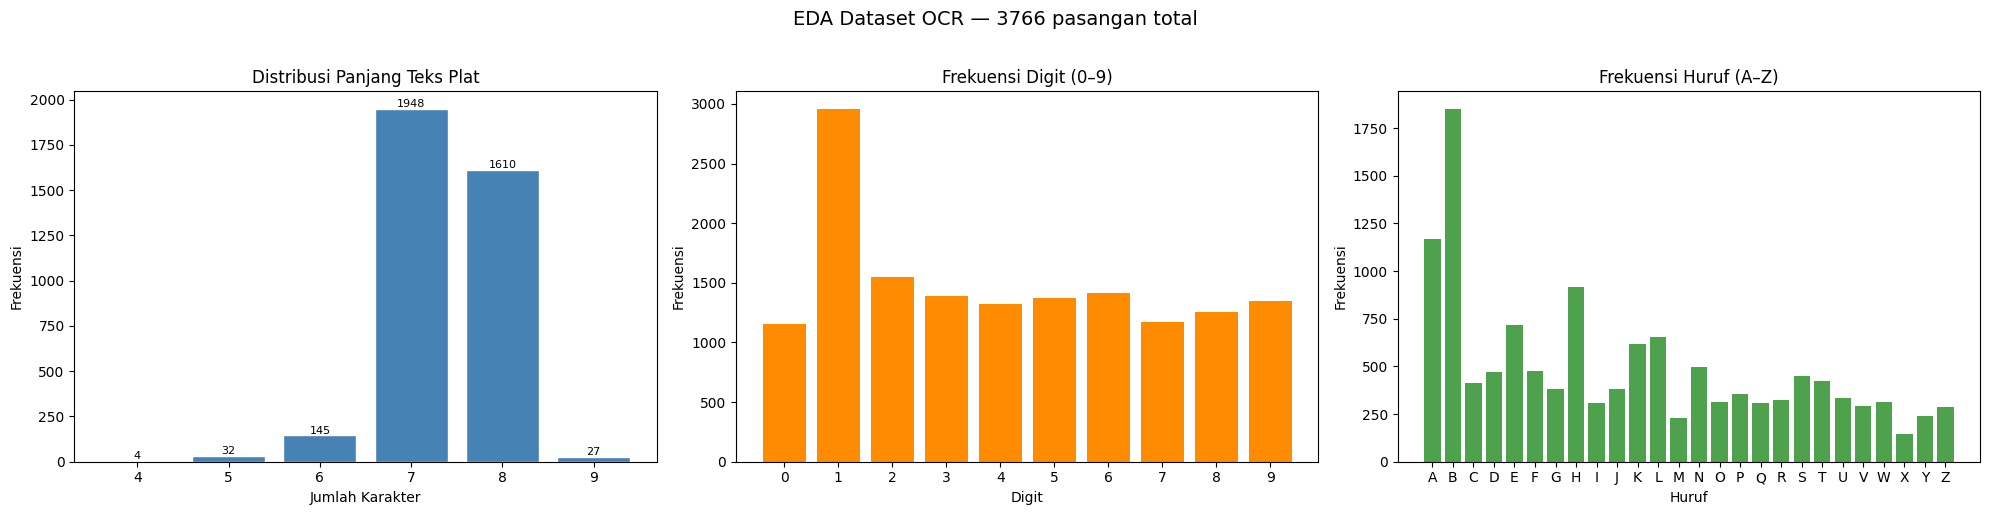

Panjang teks — Min: 4, Max: 9, Mean: 7.4
Total karakter unik: 36
Top 10 karakter    : [('1', 2958), ('B', 1850), ('2', 1552), ('6', 1415), ('3', 1388), ('5', 1371), ('9', 1346), ('4', 1326), ('8', 1256), ('A', 1169)]


In [9]:
# ============================================================
# Cell 2.4 — EDA: Analisis Distribusi Label
# ============================================================
import matplotlib.pyplot as plt
from collections import Counter

all_texts = [text for _, text in all_pairs]

# Distribusi panjang teks
lengths = [len(t) for t in all_texts]
char_freq = Counter(''.join(all_texts))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Distribusi panjang
len_counter = Counter(lengths)
axes[0].bar(len_counter.keys(), len_counter.values(), color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Panjang Teks Plat', fontsize=12)
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
for k, v in len_counter.items():
    axes[0].text(k, v + 10, str(v), ha='center', fontsize=8)

# Plot 2: Frekuensi karakter (digit vs huruf)
digits  = {k: v for k, v in char_freq.items() if k.isdigit()}
letters = {k: v for k, v in char_freq.items() if k.isalpha()}
axes[1].bar(sorted(digits.keys()), [digits[k] for k in sorted(digits.keys())],
            color='darkorange', label='Digit')
axes[1].set_title('Frekuensi Digit (0–9)', fontsize=12)
axes[1].set_xlabel('Digit')
axes[1].set_ylabel('Frekuensi')

axes[2].bar(sorted(letters.keys()), [letters[k] for k in sorted(letters.keys())],
            color='forestgreen', alpha=0.8)
axes[2].set_title('Frekuensi Huruf (A–Z)', fontsize=12)
axes[2].set_xlabel('Huruf')
axes[2].set_ylabel('Frekuensi')

plt.suptitle(f'EDA Dataset OCR — {len(all_pairs)} pasangan total', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(WORK_DIR / 'eda_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Panjang teks — Min: {min(lengths)}, Max: {max(lengths)}, Mean: {sum(lengths)/len(lengths):.1f}")
print(f"Total karakter unik: {len(char_freq)}")
print(f"Top 10 karakter    : {char_freq.most_common(10)}")


In [10]:
# ============================================================
# Cell 2.5 — Split Dataset (70:20:10)
#
# Anti data-leakage:
#   Dataset Recognition sudah punya split train/val/test sendiri,
#   tapi kita re-split semua agar distribusi seragam.
#   Shuffle dengan seed tetap untuk reproducibility.
# ============================================================

random.seed(RANDOM_SEED)
random.shuffle(all_pairs)

n_total = len(all_pairs)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

train_pairs = all_pairs[:n_train]
val_pairs   = all_pairs[n_train:n_train + n_val]
test_pairs  = all_pairs[n_train + n_val:]

print(f"Total pasangan : {n_total}")
print(f"  Train        : {len(train_pairs)} ({len(train_pairs)/n_total*100:.1f}%)")
print(f"  Val          : {len(val_pairs)} ({len(val_pairs)/n_total*100:.1f}%)")
print(f"  Test         : {len(test_pairs)} ({len(test_pairs)/n_total*100:.1f}%)")


Total pasangan : 3766
  Train        : 2636 (70.0%)
  Val          : 753 (20.0%)
  Test         : 377 (10.0%)


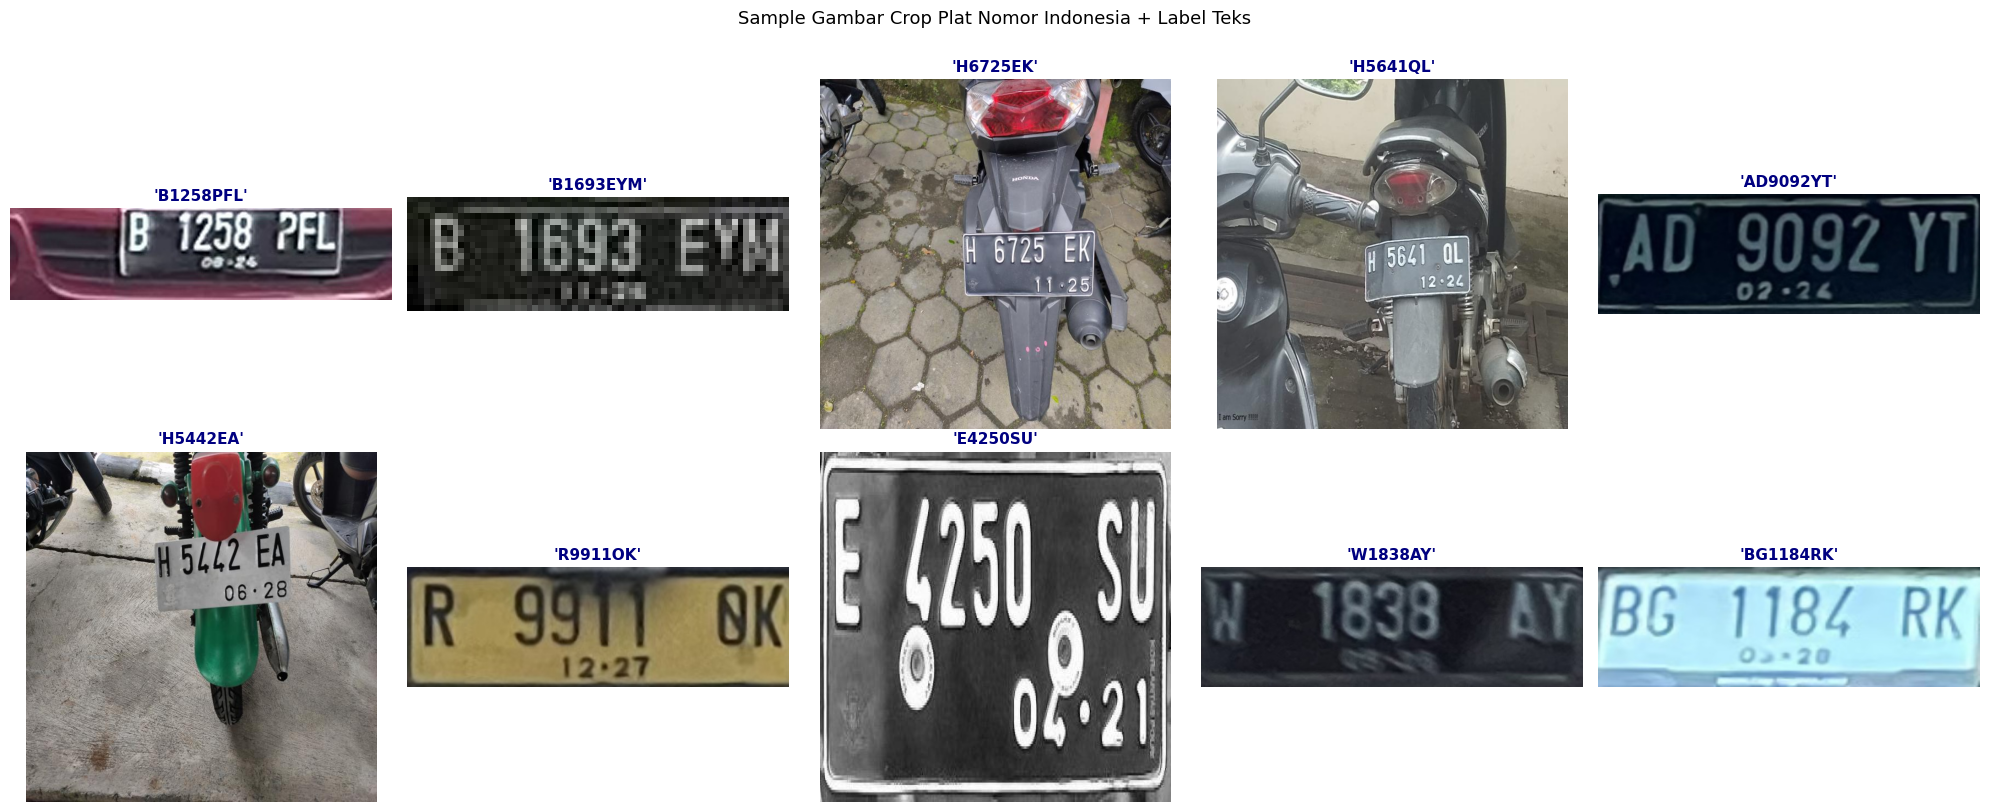

In [11]:
# ============================================================
# Cell 2.6 — Tampilkan Sample Gambar Crop Plat
# ============================================================
from PIL import Image
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

sample_idx = random.sample(range(len(train_pairs)), 10)
for i, idx in enumerate(sample_idx):
    img_path, text = train_pairs[idx]
    try:
        img = Image.open(img_path).convert('RGB')
        axes[i].imshow(img)
        axes[i].set_title(f"'{text}'", fontsize=11, color='navy', fontweight='bold')
        axes[i].axis('off')
    except Exception as e:
        axes[i].set_title(f'Error: {e}', fontsize=7)
        axes[i].axis('off')

plt.suptitle('Sample Gambar Crop Plat Nomor Indonesia + Label Teks',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(WORK_DIR / 'sample_crop_plates.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 🧩 Bagian 3: PyTorch Dataset & Preprocessing

### Pipeline Preprocessing Gambar:
```
Crop Plat (ukuran bebas)
        │
        ▼
[Standard]  Resize ke 384×128
        │
        ▼
[Enhanced]  CLAHE (contrast enhancement)
            Bilateral Filter (noise reduction)
            Adaptive Threshold (opsional)
        │
        ▼
TrOCR ViTImageProcessor (normalize ke mean/std model)
        │
        ▼
pixel_values tensor [3, H, W]
```


✅ Fungsi preprocessing siap digunakan.


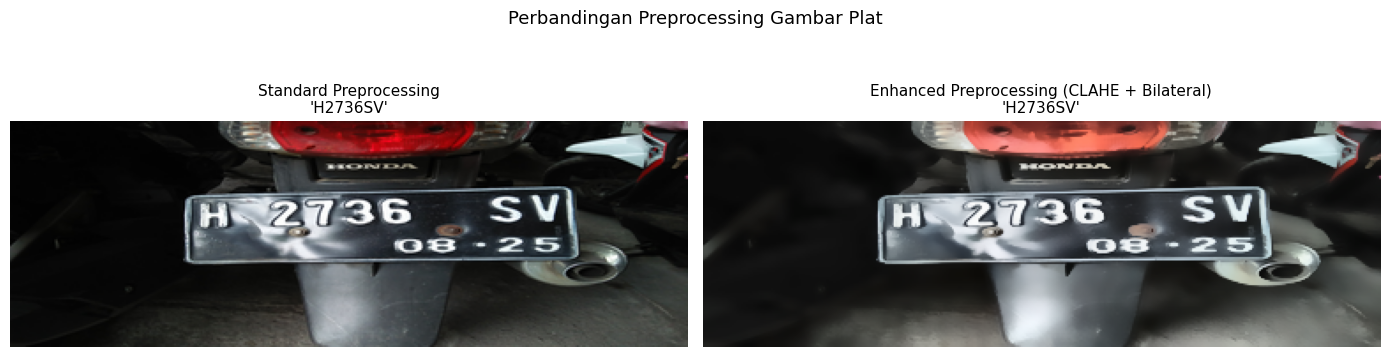

In [12]:
# ============================================================
# Cell 3.1 — Fungsi Preprocessing Gambar
# ============================================================
import cv2
import numpy as np
from PIL import Image

def preprocess_plate_standard(image_path_or_pil, target_width=384, target_height=128):
    """
    Preprocessing minimal: hanya resize ke ukuran target.
    Digunakan untuk Exp-A dan Exp-B.

    Args:
        image_path_or_pil : str path atau PIL Image
        target_width      : lebar target (default 384)
        target_height     : tinggi target (default 128)

    Returns:
        PIL.Image (RGB)
    """
    if isinstance(image_path_or_pil, str):
        img = Image.open(image_path_or_pil).convert('RGB')
    else:
        img = image_path_or_pil.convert('RGB')

    img = img.resize((target_width, target_height), Image.LANCZOS)
    return img


def preprocess_plate_enhanced(image_path_or_pil, target_width=384, target_height=128):
    """
    Preprocessing enhanced untuk kondisi nyata (basement, low-light, plat kotor):
      1. Resize ke target
      2. Convert ke LAB colorspace
      3. CLAHE pada channel L (memperkuat kontras karakter)
      4. Bilateral Filter (mengurangi noise sambil menjaga tepi karakter)
      5. Convert kembali ke RGB

    Digunakan untuk Exp-C dan Exp-D.

    CLAHE (Contrast Limited Adaptive Histogram Equalization):
      - clipLimit=2.0: batas kontras adaptif
      - tileGridSize=(8,4): grid lebih sempit karena gambar landscape

    Bilateral Filter:
      - d=9: diameter neighborhood
      - sigmaColor=75: range filter dalam colorspace
      - sigmaSpace=75: range filter dalam spatial
    """
    if isinstance(image_path_or_pil, str):
        img_pil = Image.open(image_path_or_pil).convert('RGB')
    else:
        img_pil = image_path_or_pil.convert('RGB')

    # Resize terlebih dahulu
    img_pil  = img_pil.resize((target_width, target_height), Image.LANCZOS)

    # Convert PIL → OpenCV (BGR)
    img_cv   = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

    # Konversi ke LAB colorspace
    lab      = cv2.cvtColor(img_cv, cv2.COLOR_BGR2LAB)
    l, a, b  = cv2.split(lab)

    # CLAHE pada channel L (Luminance)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 4))
    l_clahe  = clahe.apply(l)

    # Gabungkan kembali
    lab_out  = cv2.merge([l_clahe, a, b])
    img_enhanced = cv2.cvtColor(lab_out, cv2.COLOR_LAB2BGR)

    # Bilateral Filter
    img_filtered = cv2.bilateralFilter(img_enhanced, d=9, sigmaColor=75, sigmaSpace=75)

    # Convert kembali ke PIL RGB
    img_out  = Image.fromarray(cv2.cvtColor(img_filtered, cv2.COLOR_BGR2RGB))
    return img_out


print("✅ Fungsi preprocessing siap digunakan.")

# Visualisasi perbandingan Standard vs Enhanced
sample_img_path, sample_text = train_pairs[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(preprocess_plate_standard(sample_img_path))
axes[0].set_title(f"Standard Preprocessing\n'{sample_text}'", fontsize=11)
axes[0].axis('off')

axes[1].imshow(preprocess_plate_enhanced(sample_img_path))
axes[1].set_title(f"Enhanced Preprocessing (CLAHE + Bilateral)\n'{sample_text}'", fontsize=11)
axes[1].axis('off')

plt.suptitle('Perbandingan Preprocessing Gambar Plat', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(WORK_DIR / 'preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


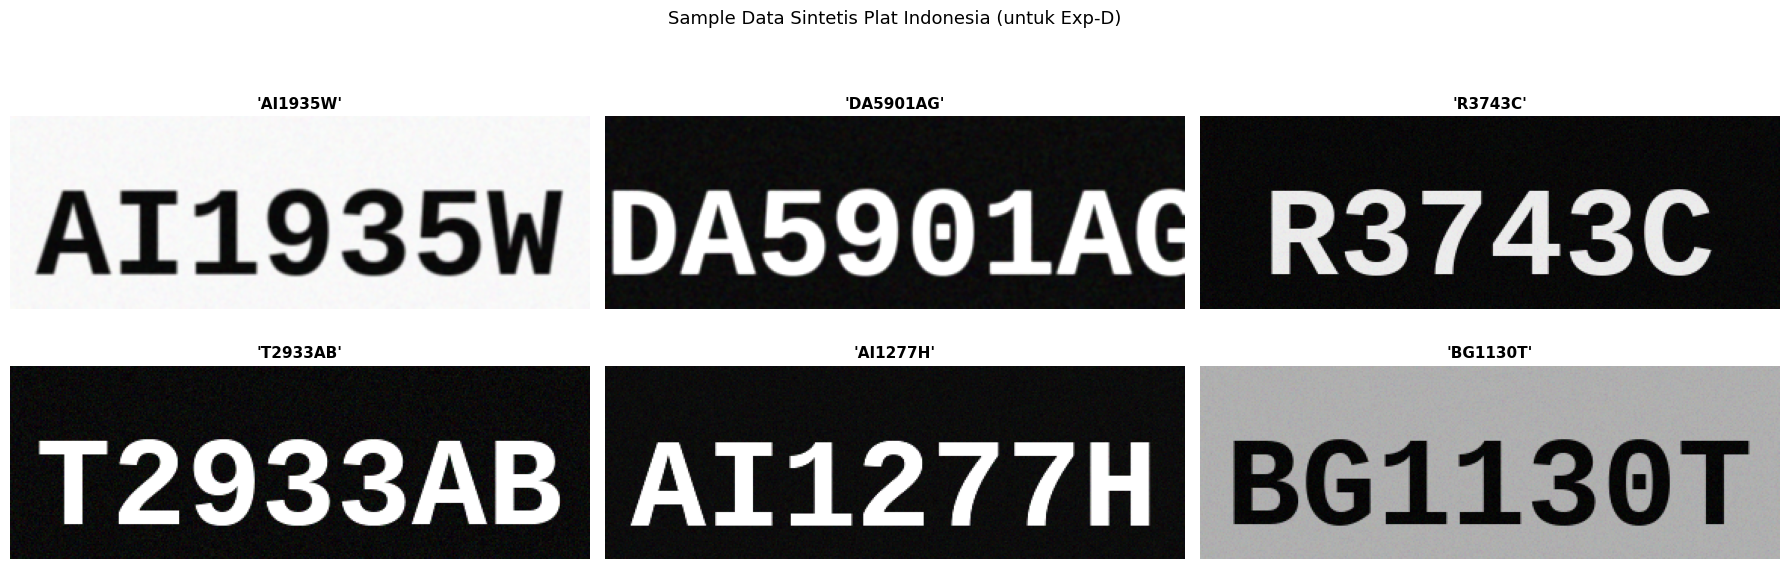

✅ Generator data sintetis siap.


In [13]:
# ============================================================
# Cell 3.2 — Generator Data Sintetis (untuk Exp-D: 2-Stage)
#
# Data sintetis dibuat dengan merender teks plat Indonesia
# di atas background hitam/putih dengan variasi noise dan blur.
# Ini mensimulasikan data pretraining sebelum fine-tuning ke plat nyata.
# ============================================================
from PIL import Image, ImageDraw, ImageFont
import random
import io

# Karakter prefix daerah umum di Indonesia
PREFIXES  = [
    'B','D','F','H','K','L','N','R','S','T','W','Z',
    'AB','AD','AE','AG','AH','AI','AM','AN','AP','BA',
    'BB','BD','BE','BG','BH','BK','BL','BM','BN','BP',
    'DA','DB','DC','DD','DE','DH','DK','DL','DM','DN'
]
SUFFIXES  = [
    'A','B','C','D','E','F','G','H','I','J','K','L','M',
    'N','P','Q','R','S','T','U','V','W','X','Y','Z',
    'AA','AB','AC','AD','AE','AF','AG','AH','AI','AJ'
]


def generate_synthetic_plate_text():
    """Generate random plate text sesuai format TNKB Indonesia."""
    prefix = random.choice(PREFIXES)
    number = str(random.randint(1, 9999)).zfill(random.randint(1, 4))
    suffix = random.choice(SUFFIXES)
    return f"{prefix}{number}{suffix}"


def render_synthetic_plate(text, width=384, height=128, dark_bg=True):
    """
    Render gambar plat nomor sintetis:
      - Background hitam (plat lama) atau putih (plat baru TNKB)
      - Font default PIL (tidak butuh file font eksternal)
      - Augmentasi: noise gaussian, blur, brightness

    Returns:
        PIL.Image (RGB)
    """
    # Warna background dan teks
    bg_color   = (10, 10, 10)    if dark_bg else (250, 250, 250)
    text_color = (255, 255, 255) if dark_bg else (10, 10, 10)

    img  = Image.new('RGB', (width, height), color=bg_color)
    draw = ImageDraw.Draw(img)

    # Estimasi posisi teks (center)
    font_size = int(height * 0.65)
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationMono-Bold.ttf",
                                   font_size)
    except IOError:
        font = ImageFont.load_default()

    # Hitung posisi tengah
    bbox = draw.textbbox((0, 0), text, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = max(0, (width - tw) // 2)
    y = max(0, (height - th) // 2)

    draw.text((x, y), text, fill=text_color, font=font)

    # Convert ke numpy untuk augmentasi
    img_np = np.array(img)

    # Gaussian noise
    noise_std = random.uniform(0, 20)
    noise = np.random.normal(0, noise_std, img_np.shape).astype(np.int16)
    img_np = np.clip(img_np.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Random blur
    if random.random() < 0.4:
        ksize = random.choice([3, 5])
        img_np = cv2.GaussianBlur(img_np, (ksize, ksize), 0)

    # Random brightness
    factor = random.uniform(0.7, 1.3)
    img_np = np.clip(img_np.astype(np.float32) * factor, 0, 255).astype(np.uint8)

    return Image.fromarray(img_np)


# Verifikasi
synth_samples = []
for _ in range(6):
    text    = generate_synthetic_plate_text()
    dark    = random.choice([True, False])
    img_syn = render_synthetic_plate(text, dark_bg=dark)
    synth_samples.append((img_syn, text))

fig, axes = plt.subplots(2, 3, figsize=(18, 6))
axes = axes.flatten()
for i, (img, text) in enumerate(synth_samples):
    axes[i].imshow(img)
    axes[i].set_title(f"'{text}'", fontsize=11, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Sample Data Sintetis Plat Indonesia (untuk Exp-D)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(WORK_DIR / 'synthetic_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Generator data sintetis siap.")


In [14]:
# ============================================================
# Cell 3.3 — PyTorch Dataset Class
# ============================================================
from torch.utils.data import Dataset
from transformers import TrOCRProcessor


class PlateOCRDataset(Dataset):
    """
    Dataset untuk fine-tuning TrOCR pada gambar crop plat nomor Indonesia.

    Mengelola:
      - Loading gambar dan preprocessing (standard atau enhanced)
      - Tokenisasi teks dengan TrOCRProcessor
      - Return: {pixel_values, labels} untuk Hugging Face Trainer

    Args:
        pairs      : list of (image_path_or_pil, label_text)
        processor  : TrOCRProcessor dari Hugging Face
        max_length : panjang maksimum sequence token output
        preprocess_fn : fungsi preprocessing gambar
        is_synthetic  : True jika gambar adalah PIL Image (bukan path)
    """

    def __init__(self, pairs, processor, max_length=MAX_TARGET_LENGTH,
                 preprocess_fn=None, is_synthetic=False):
        self.pairs         = pairs
        self.processor     = processor
        self.max_length    = max_length
        self.preprocess_fn = preprocess_fn or preprocess_plate_standard
        self.is_synthetic  = is_synthetic

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_src, text = self.pairs[idx]

        # Load & preprocess gambar
        if self.is_synthetic:
            # img_src sudah berupa PIL Image
            img_pil = img_src.convert('RGB')
        else:
            img_pil = self.preprocess_fn(img_src)

        # Proses gambar → pixel_values tensor
        pixel_values = self.processor(
            images    = img_pil,
            return_tensors = 'pt'
        ).pixel_values.squeeze(0)  # [3, H, W]

        # Tokenisasi label teks
        labels = self.processor.tokenizer(
            text,
            padding     = 'max_length',
            max_length  = self.max_length,
            truncation  = True,
            return_tensors = 'pt'
        ).input_ids.squeeze(0)  # [max_length]

        # Ganti padding token ID dengan -100 (diabaikan dalam loss)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            'pixel_values': pixel_values,
            'labels'      : labels,
        }


class SyntheticPlateDataset(Dataset):
    """
    Dataset sintetis yang men-generate gambar secara on-the-fly.
    Digunakan sebagai pretraining data untuk Exp-D (2-stage fine-tuning).

    Args:
        n_samples  : jumlah sampel sintetis yang akan di-generate
        processor  : TrOCRProcessor
        max_length : panjang maksimum token
    """

    def __init__(self, n_samples, processor, max_length=MAX_TARGET_LENGTH):
        self.n_samples  = n_samples
        self.processor  = processor
        self.max_length = max_length
        # Pre-generate semua teks agar deterministic per epoch
        random.seed(RANDOM_SEED + 99)
        self.texts = [generate_synthetic_plate_text() for _ in range(n_samples)]
        self.dark  = [random.choice([True, False]) for _ in range(n_samples)]

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        text    = self.texts[idx]
        img_pil = render_synthetic_plate(text, dark_bg=self.dark[idx])

        pixel_values = self.processor(
            images=img_pil, return_tensors='pt'
        ).pixel_values.squeeze(0)

        labels = self.processor.tokenizer(
            text, padding='max_length',
            max_length=self.max_length,
            truncation=True, return_tensors='pt'
        ).input_ids.squeeze(0)

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {'pixel_values': pixel_values, 'labels': labels}


print("✅ PlateOCRDataset dan SyntheticPlateDataset siap digunakan.")


✅ PlateOCRDataset dan SyntheticPlateDataset siap digunakan.


---
## 🔬 Bagian 4: Definisi Konfigurasi Eksperimen


In [15]:
# ============================================================
# Cell 4.1 — Konfigurasi Empat Eksperimen
# ============================================================

EXPERIMENTS = {
    "Exp-A": {
        "description"    : "Baseline Cepat — TrOCR-small + Standard Preprocess",
        "model_name"     : "microsoft/trocr-small-printed",
        "preprocess_fn"  : preprocess_plate_standard,
        "epochs"         : EPOCHS_BASELINE,
        "batch_per_gpu"  : BATCH_SIZE,
        "lr"             : LR_BASELINE,
        "warmup_ratio"   : 0.1,
        "weight_decay"   : 0.01,
        "use_synth"      : False,  # Tidak pakai data sintetis
        "synth_n"        : 0,
        "name"           : "exp_a_trocr_small",
    },
    "Exp-B": {
        "description"    : "Baseline Akurasi — TrOCR-base + Standard Preprocess (50 epoch)",
        "model_name"     : "microsoft/trocr-base-printed",
        "preprocess_fn"  : preprocess_plate_standard,
        "epochs"         : EPOCHS_FULL,
        "batch_per_gpu"  : BATCH_SIZE,
        "lr"             : LR_BASELINE,
        "warmup_ratio"   : 0.1,
        "weight_decay"   : 0.01,
        "use_synth"      : False,
        "synth_n"        : 0,
        "name"           : "exp_b_trocr_base_standard",
    },
    "Exp-C": {
        "description"    : "RECOMMENDED — TrOCR-base + Enhanced Preprocess (CLAHE+Bilateral)",
        "model_name"     : "microsoft/trocr-base-printed",
        "preprocess_fn"  : preprocess_plate_enhanced,
        "epochs"         : EPOCHS_FULL,
        "batch_per_gpu"  : BATCH_SIZE,
        "lr"             : LR_FULL,
        "warmup_ratio"   : 0.15,
        "weight_decay"   : 0.01,
        "use_synth"      : False,
        "synth_n"        : 0,
        "name"           : "exp_c_trocr_base_enhanced",
    },
    "Exp-D": {
        "description"    : "Research/Advanced — TrOCR-base + Synth→Real (2-Stage Fine-Tuning)",
        "model_name"     : "microsoft/trocr-base-printed",
        "preprocess_fn"  : preprocess_plate_enhanced,
        "epochs"         : EPOCHS_FULL,
        "batch_per_gpu"  : BATCH_SIZE,
        "lr"             : LR_FULL,
        "warmup_ratio"   : 0.15,
        "weight_decay"   : 0.01,
        "use_synth"      : True,   # Gunakan data sintetis di stage 1
        "synth_n"        : 5000,   # Jumlah gambar sintetis untuk stage 1
        "name"           : "exp_d_trocr_base_synth_real",
    },
}

print("=" * 65)
print("KONFIGURASI EKSPERIMEN OCR")
print("=" * 65)
for exp_id, cfg in EXPERIMENTS.items():
    print(f"\n[{exp_id}] {cfg['description']}")
    print(f"  Base Model : {cfg['model_name']}")
    print(f"  Epochs     : {cfg['epochs']}")
    print(f"  LR         : {cfg['lr']}")
    print(f"  Synth Data : {'Yes (' + str(cfg['synth_n']) + ' samples)' if cfg['use_synth'] else 'No'}")

KONFIGURASI EKSPERIMEN OCR

[Exp-A] Baseline Cepat — TrOCR-small + Standard Preprocess
  Base Model : microsoft/trocr-small-printed
  Epochs     : 20
  LR         : 5e-05
  Synth Data : No

[Exp-B] Baseline Akurasi — TrOCR-base + Standard Preprocess (50 epoch)
  Base Model : microsoft/trocr-base-printed
  Epochs     : 50
  LR         : 5e-05
  Synth Data : No

[Exp-C] RECOMMENDED — TrOCR-base + Enhanced Preprocess (CLAHE+Bilateral)
  Base Model : microsoft/trocr-base-printed
  Epochs     : 50
  LR         : 0.0001
  Synth Data : No

[Exp-D] Research/Advanced — TrOCR-base + Synth→Real (2-Stage Fine-Tuning)
  Base Model : microsoft/trocr-base-printed
  Epochs     : 50
  LR         : 0.0001
  Synth Data : Yes (5000 samples)


---
## 🚀 Bagian 5: Training TrOCR (Fine-Tuning)

### Strategi Fine-Tuning:
```
microsoft/trocr-*-printed
(pretrained pada dokumen cetak / printed text)
             │
             │  Fine-Tuning
             ▼
  Model khusus plat nomor Indonesia
  (karakter A-Z, 0-9, tanpa spasi/tanda baca)
```

**Alasan TrOCR:**
- Arsitektur Encoder-Decoder (ViT + RoBERTa)
- Encoder memahami gambar secara visual (Vision Transformer)
- Decoder menghasilkan urutan karakter secara autoregressive
- Pretrained pada printed text → Transfer learning sangat efektif untuk plat nomor


In [16]:
# ============================================================
# Cell 5.1 — Fungsi Perhitungan Metrik CER & Exact Match
# ============================================================
import evaluate

cer_metric = evaluate.load("cer")


def compute_metrics(pred, processor):
    """
    Hitung metrik evaluasi untuk OCR:
      - CER  (Character Error Rate)    : makin rendah makin baik
      - Exact Match Accuracy           : makin tinggi makin baik
      - Levenshtein Distance rata-rata : makin rendah makin baik

    Args:
        pred      : EvalPrediction dari Hugging Face Trainer
        processor : TrOCRProcessor untuk decode token

    Returns:
        dict dengan nilai metrik
    """
    pred_ids   = pred.predictions
    if isinstance(pred_ids, tuple):
        pred_ids = pred_ids[0]
    if hasattr(pred_ids, "ndim") and pred_ids.ndim == 3:
        pred_ids = pred_ids.argmax(axis=-1)
    label_ids  = pred.label_ids

    # Ganti -100 dengan pad_token_id sebelum decode
    pad_id     = processor.tokenizer.pad_token_id
    label_ids[label_ids == -100] = pad_id

    # Decode prediksi dan label
    pred_strs  = processor.batch_decode(pred_ids,  skip_special_tokens=True)
    label_strs = processor.batch_decode(label_ids, skip_special_tokens=True)

    # Uppercase dan filter hanya karakter valid
    pred_strs  = [''.join(c for c in p.upper() if c in VALID_CHARS) for p in pred_strs]
    label_strs = [''.join(c for c in l.upper() if c in VALID_CHARS) for l in label_strs]

    # CER (Character Error Rate)
    cer_val = cer_metric.compute(predictions=pred_strs, references=label_strs)

    # Exact Match Accuracy
    exact_match = sum(p == l for p, l in zip(pred_strs, label_strs)) / len(label_strs)

    # Levenshtein Distance rata-rata
    def lev_dist(s1, s2):
        m, n = len(s1), len(s2)
        dp = [[0]*(n+1) for _ in range(m+1)]
        for i in range(m+1): dp[i][0] = i
        for j in range(n+1): dp[0][j] = j
        for i in range(1, m+1):
            for j in range(1, n+1):
                cost = 0 if s1[i-1] == s2[j-1] else 1
                dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)
        return dp[m][n]

    avg_lev = sum(lev_dist(p, l) for p, l in zip(pred_strs, label_strs)) / len(label_strs)

    return {
        'cer'          : round(cer_val, 4),
        'exact_match'  : round(exact_match, 4),
        'avg_lev_dist' : round(avg_lev, 4),
    }


print("✅ Fungsi metrik CER & Exact Match siap.")


✅ Fungsi metrik CER & Exact Match siap.


In [17]:
# ============================================================
# Cell 5.2 — Fungsi Training Satu Eksperimen TrOCR (Optimized T4x2)
# ============================================================
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
    default_data_collator,
)
from torch.utils.data import ConcatDataset
import gc
import functools
import warnings
warnings.filterwarnings("ignore", message=".*Was asked to gather along dimension 0.*")


def train_ocr_experiment(exp_id, exp_cfg, train_pairs, val_pairs, output_dir):
    """
    Fine-tuning TrOCR untuk satu konfigurasi eksperimen.
    Dioptimalkan untuk GPU Kaggle T4x2 dengan fast generation eval.

    Args:
        exp_id     : ID eksperimen ('Exp-A' dst)
        exp_cfg    : dict konfigurasi
        train_pairs: list (img_path, text) untuk training
        val_pairs  : list (img_path, text) untuk validasi
        output_dir : direktori output

    Returns:
        best_checkpoint_dir (str), final_metrics (dict)
    """
    print("\n" + "═" * 65)
    print(f"  TRAINING: [{exp_id}] {exp_cfg['description']}")
    print("═" * 65)
    print(f"  Base Model : {exp_cfg['model_name']}")
    print(f"  Epochs     : {exp_cfg['epochs']}")
    print(f"  LR         : {exp_cfg['lr']}")
    print(f"  Synth Data : {'Yes' if exp_cfg['use_synth'] else 'No'}")
    print("═" * 65)

    exp_output = Path(output_dir) / exp_cfg['name']
    exp_output.mkdir(parents=True, exist_ok=True)

    # ─── Load Processor & Model ────────────────────────────────────────────────
    processor = TrOCRProcessor.from_pretrained(exp_cfg['model_name'])
    model     = VisionEncoderDecoderModel.from_pretrained(exp_cfg['model_name'])

    # ─── Konfigurasi Token IDs ────────────────────────────────────────────────
    model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
    model.config.pad_token_id           = processor.tokenizer.pad_token_id
    model.config.eos_token_id           = processor.tokenizer.sep_token_id

    # ─── Parameter Generasi WAJIB diatur pada generation_config (Transformers >= 4.45) ──
    model.generation_config.decoder_start_token_id = processor.tokenizer.cls_token_id
    model.generation_config.pad_token_id           = processor.tokenizer.pad_token_id
    model.generation_config.eos_token_id           = processor.tokenizer.sep_token_id
    model.generation_config.max_length             = MAX_TARGET_LENGTH
    model.generation_config.no_repeat_ngram_size   = 3
    # num_beams=1 (greedy search) saat training eval agar evaluasi berjalan 10x lebih cepat!
    model.generation_config.num_beams              = 1
    # Hapus parameter beam-only yang tidak kompatibel dengan greedy (num_beams=1)
    model.generation_config.length_penalty    = 1.0  # reset, hanya berlaku num_beams>1
    model.generation_config.early_stopping    = False

    # Fungsi metrics dengan closure untuk processor
    compute_fn = functools.partial(compute_metrics, processor=processor)

    # ─── Hitung warmup_steps secara eksplisit (menggantikan warmup_ratio deprecated) ──
    effective_batch = exp_cfg['batch_per_gpu'] * max(1, N_GPU)
    total_train_steps = (len(train_pairs) // effective_batch) * exp_cfg['epochs']
    warmup_steps = max(10, int(total_train_steps * exp_cfg.get('warmup_ratio', 0.1)))

    print(f"  Effective Batch Size: {effective_batch} ({exp_cfg['batch_per_gpu']} per GPU x {max(1, N_GPU)} GPU)")
    print(f"  Steps per Epoch     : {len(train_pairs) // effective_batch}")
    print(f"  Total Steps         : {total_train_steps} (Warmup: {warmup_steps})")

    # ─── Stage 1 (Exp-D saja): Pre-training dengan data sintetis ──────────────
    if exp_cfg['use_synth'] and exp_cfg['synth_n'] > 0:
        print(f"\n[Stage 1] Pre-training dengan {exp_cfg['synth_n']} data sintetis...")

        synth_dataset = SyntheticPlateDataset(
            n_samples = exp_cfg['synth_n'],
            processor = processor,
        )

        val_ds_stage1 = PlateOCRDataset(
            pairs          = val_pairs,
            processor      = processor,
            preprocess_fn  = exp_cfg['preprocess_fn'],
        )

        args_stage1 = Seq2SeqTrainingArguments(
            output_dir                  = str(exp_output / "stage1"),
            num_train_epochs            = 10,
            per_device_train_batch_size = exp_cfg['batch_per_gpu'],
            per_device_eval_batch_size  = exp_cfg['batch_per_gpu'],
            learning_rate               = exp_cfg['lr'],
            warmup_steps                = max(10, int(exp_cfg['synth_n'] // effective_batch * 10 * 0.1)),
            weight_decay                = exp_cfg['weight_decay'],
            predict_with_generate       = True,
            generation_num_beams        = 1,
            eval_strategy               = "epoch",
            save_strategy               = "epoch",
            logging_steps               = 25,
            fp16                        = True,    # AMP (Tensor Cores T4)
            dataloader_num_workers      = NUM_WORKERS,
            dataloader_pin_memory       = True,
            seed                        = RANDOM_SEED,
            report_to                   = "none",
        )

        trainer_s1 = Seq2SeqTrainer(
            model          = model,
            args           = args_stage1,
            train_dataset  = synth_dataset,
            eval_dataset   = val_ds_stage1,
            compute_metrics= compute_fn,
        )
        trainer_s1.train()
        print("[Stage 1] ✅ Pre-training sintetis selesai. Lanjut ke Stage 2...")

    # ─── Stage 2 (semua eksperimen): Fine-tuning dengan data riil ─────────────
    stage_label = "Stage 2" if exp_cfg['use_synth'] else "Fine-Tuning"
    print(f"\n[{stage_label}] Fine-tuning dengan data plat riil Indonesia...")

    train_ds = PlateOCRDataset(
        pairs          = train_pairs,
        processor      = processor,
        preprocess_fn  = exp_cfg['preprocess_fn'],
    )
    val_ds = PlateOCRDataset(
        pairs          = val_pairs,
        processor      = processor,
        preprocess_fn  = exp_cfg['preprocess_fn'],
    )

    training_args = Seq2SeqTrainingArguments(
        output_dir                  = str(exp_output),
        num_train_epochs            = exp_cfg['epochs'],
        per_device_train_batch_size = exp_cfg['batch_per_gpu'],
        per_device_eval_batch_size  = exp_cfg['batch_per_gpu'],
        learning_rate               = exp_cfg['lr'],
        warmup_steps                = warmup_steps,
        weight_decay                = exp_cfg['weight_decay'],

        # ─── Evaluasi & Checkpoint ─────────────────────────────────────────
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "cer",
        greater_is_better           = False,
        save_total_limit            = 2,

        # ─── Fast Generation Config untuk TrOCR ────────────────────────────
        predict_with_generate       = True,
        generation_max_length       = MAX_TARGET_LENGTH,
        generation_num_beams        = 1,       # 10x lebih cepat dibanding beam=4!

        # ─── Logging & Hardware Acceleration ──────────────────────────────
        logging_steps               = 25,
        report_to                   = "none",
        fp16                        = True,    # Mixed Precision AMP T4
        dataloader_num_workers      = NUM_WORKERS,
        dataloader_pin_memory       = True,    # Fast host-to-device memory
        seed                        = RANDOM_SEED,
    )

    trainer = Seq2SeqTrainer(
        model           = model,
        args            = training_args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_fn,
        callbacks       = [
            EarlyStoppingCallback(early_stopping_patience=PATIENCE)
        ],
    )

    train_result = trainer.train()

    # Simpan model terbaik
    best_ckpt = trainer.state.best_model_checkpoint
    final_save = exp_output / "best_model"
    trainer.save_model(str(final_save))
    processor.save_pretrained(str(final_save))

    print(f"\n✅ Training [{exp_id}] selesai!")
    print(f"   Best checkpoint  : {best_ckpt}")
    print(f"   Best model saved : {final_save}")

    # Bersihkan memori GPU
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

    return str(final_save), train_result.metrics


print("✅ Fungsi training TrOCR (Optimized T4x2) siap.")


✅ Fungsi training TrOCR (Optimized T4x2) siap.


In [18]:
# ============================================================
# Cell 5.3 — PILIH EKSPERIMEN YANG AKAN DIJALANKAN
#
# ⚠️ REKOMENDASI PENGGUNAAN KUOTA GPU KAGGLE (30 jam/minggu):
#
#   Sesi 1: ["Exp-A", "Exp-B"] → angka baseline (~2–3 jam)
#   Sesi 2: ["Exp-C"]          → model RECOMMENDED (~3–4 jam)
#   Sesi 3: ["Exp-D"]          → advanced, 2-stage training (~4–5 jam)
#
#   Ubah list di bawah sesuai sesi saat ini:
# ============================================================

EXPERIMENTS_TO_RUN = ["Exp-B"]  # <- Sesi ini: Exp-B (50 epoch). Ganti ke ["Exp-C"] untuk sesi berikutnya

RESULTS_DIR = WORK_DIR / "training_results"
RESULTS_DIR.mkdir(exist_ok=True)

print("Eksperimen yang akan dijalankan sesi ini:")
for exp_id in EXPERIMENTS_TO_RUN:
    cfg = EXPERIMENTS[exp_id]
    est_hr = (cfg['epochs'] * len(train_pairs) / cfg['batch_per_gpu'] / N_GPU / 100) / 60
    print(f"  [{exp_id}] {cfg['description']}")
    print(f"         estimasi ~{est_hr:.1f} jam pada T4x2")

Eksperimen yang akan dijalankan sesi ini:
  [Exp-B] Baseline Akurasi — TrOCR-base + Standard Preprocess (50 epoch)
         estimasi ~0.7 jam pada T4x2


In [19]:
# ============================================================
# Cell 5.4 — EKSEKUSI TRAINING
# ============================================================

exp_results = {}
best_models = {}

for exp_id in EXPERIMENTS_TO_RUN:
    exp_cfg = EXPERIMENTS[exp_id]

    try:
        best_model_dir, train_metrics = train_ocr_experiment(
            exp_id      = exp_id,
            exp_cfg     = exp_cfg,
            train_pairs = train_pairs,
            val_pairs   = val_pairs,
            output_dir  = RESULTS_DIR,
        )
        best_models[exp_id] = best_model_dir
        exp_results[exp_id] = train_metrics

    except Exception as e:
        print(f"\n❌ Training [{exp_id}] gagal: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "═" * 50)
print("SEMUA TRAINING SELESAI")
print("═" * 50)
for exp_id, path in best_models.items():
    exists = Path(path).exists()
    status = "✅" if exists else "❌ Missing"
    print(f"  {status} [{exp_id}] Best model: {path}")



═════════════════════════════════════════════════════════════════
  TRAINING: [Exp-B] Baseline Akurasi — TrOCR-base + Standard Preprocess (50 epoch)
═════════════════════════════════════════════════════════════════
  Base Model : microsoft/trocr-base-printed
  Epochs     : 50
  LR         : 5e-05
  Synth Data : No
═════════════════════════════════════════════════════════════════


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Training [Exp-B] selesai!
   Best checkpoint  : /kaggle/working/ocr_plate_recognizer/training_results/exp_b_trocr_base_standard/checkpoint-4150
   Best model saved : /kaggle/working/ocr_plate_recognizer/training_results/exp_b_trocr_base_standard/best_model

══════════════════════════════════════════════════
SEMUA TRAINING SELESAI
══════════════════════════════════════════════════
  ✅ [Exp-B] Best model: /kaggle/working/ocr_plate_recognizer/training_results/exp_b_trocr_base_standard/best_model


---
## 📈 Bagian 6: Evaluasi & Perbandingan


In [20]:
# ============================================================
# Cell 6.1 — Evaluasi pada Test Set
# ============================================================
import functools

evaluation_summary = {}  # {exp_id: {cer, exact_match, avg_lev_dist}}
pred_sample_log    = {}  # {exp_id: [(text_pred, text_true), ...]}

for exp_id, model_dir in best_models.items():
    if not Path(model_dir).exists():
        print(f"⚠️ [{exp_id}] Lewati — model tidak ditemukan.")
        continue

    print(f"\n[{exp_id}] Evaluasi pada Test Set ({len(test_pairs)} sampel)...")

    processor = TrOCRProcessor.from_pretrained(model_dir)
    model     = VisionEncoderDecoderModel.from_pretrained(model_dir)
    model.eval()

    # Jika T4x2: gunakan DataParallel untuk inferensi paralel
    if N_GPU > 1:
        model = torch.nn.DataParallel(model)
    model = model.to('cuda' if torch.cuda.is_available() else 'cpu')

    exp_cfg    = EXPERIMENTS[exp_id]
    test_ds    = PlateOCRDataset(
        pairs         = test_pairs,
        processor     = processor,
        preprocess_fn = exp_cfg['preprocess_fn'],
    )

    from torch.utils.data import DataLoader
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE * N_GPU, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            pv     = batch['pixel_values'].to('cuda' if torch.cuda.is_available() else 'cpu')
            gen_model = model.module if hasattr(model, 'module') else model
            gen_ids   = gen_model.generate(
                pv,
                max_length = MAX_TARGET_LENGTH,
                num_beams  = 4,
            )
            pred_text  = processor.batch_decode(gen_ids, skip_special_tokens=True)

            lbl_ids = batch['labels'].clone()
            lbl_ids[lbl_ids == -100] = processor.tokenizer.pad_token_id
            label_text = processor.batch_decode(lbl_ids, skip_special_tokens=True)

            # Normalisasi: uppercase, filter valid chars
            pred_text  = [''.join(c for c in p.upper() if c in VALID_CHARS) for p in pred_text]
            label_text = [''.join(c for c in l.upper() if c in VALID_CHARS) for l in label_text]

            all_preds.extend(pred_text)
            all_labels.extend(label_text)

    # Hitung metrik
    cer_val     = cer_metric.compute(predictions=all_preds, references=all_labels)
    exact_match = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)

    evaluation_summary[exp_id] = {
        'CER'              : round(cer_val, 4),
        'Exact Match (%)' : round(exact_match * 100, 2),
        'Samples'         : len(all_labels),
    }

    # Simpan sampel prediksi
    pred_sample_log[exp_id] = list(zip(all_preds[:10], all_labels[:10]))

    print(f"  CER          : {cer_val:.4f}")
    print(f"  Exact Match  : {exact_match*100:.2f}%")

    # Cleanup
    del model, processor, test_ds, test_loader
    gc.collect()
    torch.cuda.empty_cache()

print("\nEvaluasi selesai.")



[Exp-B] Evaluasi pada Test Set (377 sampel)...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

  CER          : 0.0262
  Exact Match  : 85.15%

Evaluasi selesai.


In [21]:
# ============================================================
# Cell 6.2 — Tabel Perbandingan Metrik
# ============================================================
import pandas as pd

summary_rows = []
for exp_id, metrics in evaluation_summary.items():
    cfg = EXPERIMENTS[exp_id]
    row = {
        'Eksperimen'    : exp_id,
        'Base Model'    : cfg['model_name'].replace('microsoft/', ''),
        'Preprocessing' : 'Enhanced' if cfg['preprocess_fn'] == preprocess_plate_enhanced else 'Standard',
        'Synth Data'    : 'Yes' if cfg['use_synth'] else 'No',
        'Epochs'        : cfg['epochs'],
        **metrics,
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

print("=" * 90)
print("TABEL PERBANDINGAN HASIL EKSPERIMEN OCR — TEST SET")
print("=" * 90)
print(df_summary.to_string(index=False))

csv_path = WORK_DIR / 'ocr_experiment_comparison.csv'
df_summary.to_csv(csv_path, index=False)
print(f"\n✅ Disimpan ke: {csv_path}")

# Model terbaik (CER terendah)
if len(df_summary) > 0 and 'CER' in df_summary.columns:
    best_row = df_summary.loc[df_summary['CER'].idxmin()]
    print(f"\n🏆 Model Terbaik (CER terendah): [{best_row['Eksperimen']}]")
    print(f"   CER          : {best_row['CER']}")
    print(f"   Exact Match  : {best_row['Exact Match (%)']}%")


TABEL PERBANDINGAN HASIL EKSPERIMEN OCR — TEST SET
Eksperimen         Base Model Preprocessing Synth Data  Epochs    CER  Exact Match (%)  Samples
     Exp-B trocr-base-printed      Standard         No      50 0.0262            85.15      377

✅ Disimpan ke: /kaggle/working/ocr_plate_recognizer/ocr_experiment_comparison.csv

🏆 Model Terbaik (CER terendah): [Exp-B]
   CER          : 0.0262
   Exact Match  : 85.15%


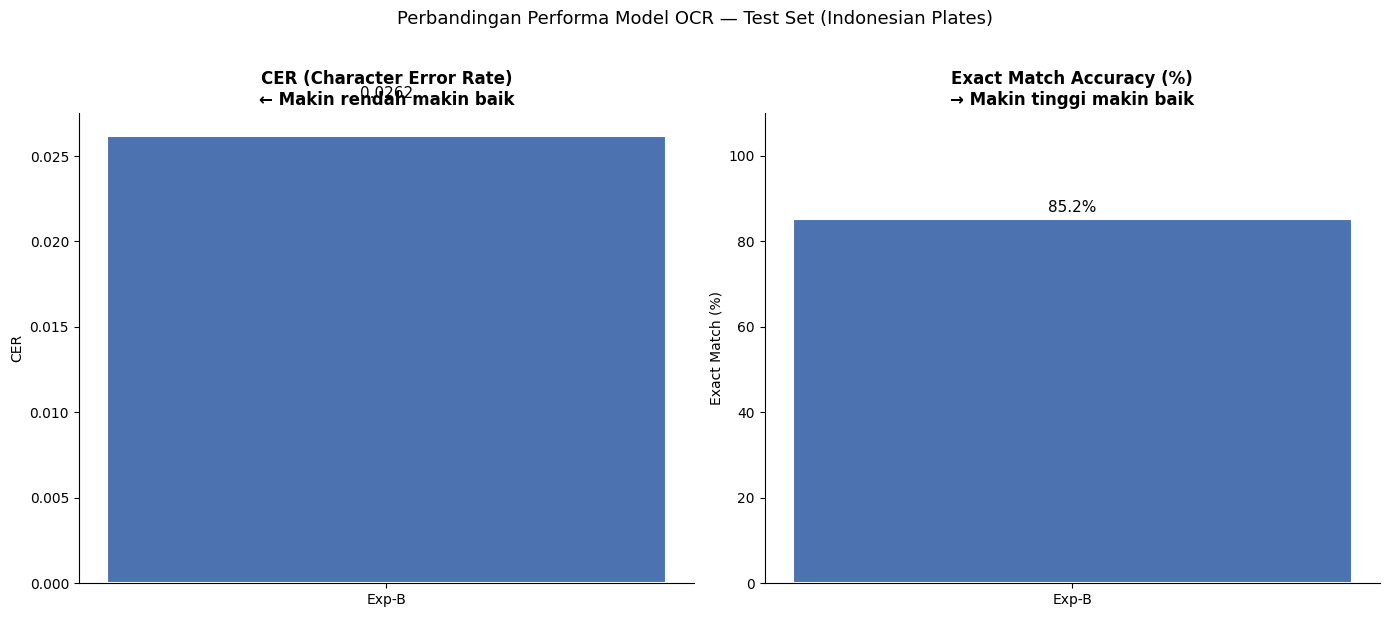

✅ Plot disimpan.


In [22]:
# ============================================================
# Cell 6.3 — Visualisasi Perbandingan Metrik
# ============================================================

if len(df_summary) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    exp_labels = df_summary['Eksperimen'].tolist()

    # CER (lower is better)
    cer_vals = df_summary['CER'].tolist()
    bars = axes[0].bar(exp_labels, cer_vals, color=colors[:len(exp_labels)],
                       edgecolor='white', linewidth=1.5)
    axes[0].set_title('CER (Character Error Rate)\n← Makin rendah makin baik',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('CER')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.002,
                     f'{h:.4f}', ha='center', va='bottom', fontsize=11)

    # Exact Match (higher is better)
    em_vals = df_summary['Exact Match (%)'].tolist()
    bars = axes[1].bar(exp_labels, em_vals, color=colors[:len(exp_labels)],
                       edgecolor='white', linewidth=1.5)
    axes[1].set_title('Exact Match Accuracy (%)\n→ Makin tinggi makin baik',
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Exact Match (%)')
    axes[1].set_ylim(0, 110)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., h + 1,
                     f'{h:.1f}%', ha='center', va='bottom', fontsize=11)

    plt.suptitle('Perbandingan Performa Model OCR — Test Set (Indonesian Plates)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(WORK_DIR / 'ocr_metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Plot disimpan.")


In [23]:
# ============================================================
# Cell 6.4 — Tabel Prediksi vs Ground Truth (Qualitative Analysis)
# ============================================================

print("=" * 70)
print("SAMPLE PREDIKSI vs GROUND TRUTH — 10 SAMPEL PER EKSPERIMEN")
print("=" * 70)

for exp_id, samples in pred_sample_log.items():
    print(f"\n[{exp_id}] {EXPERIMENTS[exp_id]['description']}")
    print(f"  {'No':>3}  {'Ground Truth':>15}  {'Prediksi':>15}  {'Status':>8}")
    print(f"  {'─'*3}  {'─'*15}  {'─'*15}  {'─'*8}")
    for i, (pred, true) in enumerate(samples, 1):
        status = "✅ MATCH" if pred == true else f"❌ (edit={sum(a!=b for a,b in zip(pred.ljust(len(true)), true))})"
        print(f"  {i:>3}  {true:>15}  {pred:>15}  {status}")


SAMPLE PREDIKSI vs GROUND TRUTH — 10 SAMPEL PER EKSPERIMEN

[Exp-B] Baseline Akurasi — TrOCR-base + Standard Preprocess (50 epoch)
   No     Ground Truth         Prediksi    Status
  ───  ───────────────  ───────────────  ────────
    1          H1103HR          H1103HK  ❌ (edit=1)
    2         AA8417MA         AA8417MA  ✅ MATCH
    3           L1722B           L1722B  ✅ MATCH
    4         BG1156VX         AG1156VX  ❌ (edit=1)
    5         B2005POU         B2005POU  ✅ MATCH
    6           4740CS          G7440CS  ❌ (edit=4)
    7         AB1975RX         AB1975RX  ✅ MATCH
    8         B1578TJI          B1518TJ  ❌ (edit=2)
    9         AB3767XY         AB3767XY  ✅ MATCH
   10          G9058EJ          G9058EJ  ✅ MATCH


In [24]:
# ============================================================
# Cell 6.5 — Analisis Kesalahan per Karakter (Error Analysis)
# ============================================================
from collections import defaultdict

# Gunakan model terbaik untuk error analysis
if evaluation_summary and len(df_summary) > 0 and 'CER' in df_summary.columns:
    best_exp_id = df_summary.loc[df_summary['CER'].idxmin()]['Eksperimen']

    if best_exp_id in pred_sample_log:
        # Kumpulkan pasangan karakter (pred → true) dari semua sampel
        char_errors = defaultdict(lambda: defaultdict(int))

        for pred, true in pred_sample_log[best_exp_id]:
            # Alignment karakter sederhana (zip, bukan edit distance alignment)
            for p_char, t_char in zip(pred.ljust(len(true)), true.ljust(len(pred))):
                if p_char != t_char:
                    char_errors[t_char][p_char] += 1

        # Tampilkan kebingungan karakter (confusion) yang paling sering
        print(f"\n[{best_exp_id}] Pola Kesalahan Karakter yang Paling Sering:")
        print(f"  {'Ground Truth':>15}  {'Diprediksi':>12}  {'Count':>6}")
        print(f"  {'─'*15}  {'─'*12}  {'─'*6}")

        # Kumpulkan semua error dan sort by count
        all_errors = []
        for true_char, pred_dict in char_errors.items():
            for pred_char, count in pred_dict.items():
                all_errors.append((true_char, pred_char, count))
        all_errors.sort(key=lambda x: -x[2])

        for true_char, pred_char, count in all_errors[:15]:
            print(f"  {true_char:>15}  {'→':>3} {pred_char:<10}  {count:>6}")

        print("\n💡 Catatan: Kesalahan O vs 0, B vs 8, I vs 1 adalah tipikal OCR plat nomor")
        print("   dan bisa diminimalkan dengan post-processing Regex di Notebook 3.")



[Exp-B] Pola Kesalahan Karakter yang Paling Sering:
     Ground Truth    Diprediksi   Count
  ───────────────  ────────────  ──────
                R    → K                1
                B    → A                1
                4    → G                1
                0    → 4                1
                C    → 0                1
                S    → C                1
                     → S                1
                7    → 1                1
                I    →                  1

💡 Catatan: Kesalahan O vs 0, B vs 8, I vs 1 adalah tipikal OCR plat nomor
   dan bisa diminimalkan dengan post-processing Regex di Notebook 3.


---
## 💾 Bagian 7: Simpan Model & Ringkasan Akhir


In [25]:
# ============================================================
# Cell 7.1 — Copy Model Terbaik ke /kaggle/working/final_ocr_models/
# ============================================================
import shutil
import json

final_output_dir = KAGGLE_WORKING / "final_ocr_models"
final_output_dir.mkdir(exist_ok=True)

final_model_registry = {}

for exp_id, model_dir in best_models.items():
    src_dir  = Path(model_dir)
    dest_dir = final_output_dir / f"ocr_{exp_id.lower().replace('-', '_')}"

    if src_dir.exists():
        if dest_dir.exists():
            shutil.rmtree(dest_dir)
        shutil.copytree(src_dir, dest_dir)
        final_model_registry[exp_id] = {
            'directory'   : str(dest_dir),
            'base_model'  : EXPERIMENTS[exp_id]['model_name'],
            'description' : EXPERIMENTS[exp_id]['description'],
            'metrics'     : evaluation_summary.get(exp_id, {}),
        }
        print(f"✅ [{exp_id}] → {dest_dir}")
    else:
        print(f"⚠️ [{exp_id}] Model tidak ada, skip.")

# Simpan registry
registry_path = final_output_dir / 'model_registry.json'
with open(registry_path, 'w') as f:
    json.dump(final_model_registry, f, indent=2)

print(f"\n✅ Registry disimpan: {registry_path}")

# Tampilkan ukuran total
print("\nUkuran model yang disimpan:")
for exp_id, info in final_model_registry.items():
    d = Path(info['directory'])
    size_mb = sum(f.stat().st_size for f in d.rglob('*') if f.is_file()) / 1024**2
    print(f"  [{exp_id}] {d.name}: {size_mb:.1f} MB")


✅ [Exp-B] → /kaggle/working/final_ocr_models/ocr_exp_b

✅ Registry disimpan: /kaggle/working/final_ocr_models/model_registry.json

Ukuran model yang disimpan:
  [Exp-B] ocr_exp_b: 1277.3 MB


In [26]:
# ============================================================
# Cell 7.2 — Ringkasan Akhir Notebook 2
# ============================================================

print("\n" + "═" * 70)
print("  📋 RINGKASAN AKHIR — NOTEBOOK 2: OCR PLATE RECOGNIZER")
print("═" * 70)

print(f"\n📦 DATASET YANG DIGUNAKAN:")
print(f"   plate_text_dataset          : {len(pairs_ds1)} pasangan")
print(f"   Indonesian Recognition DS   : {len(pairs_ds2)} pasangan")
print(f"   Total                       : {len(all_pairs)} pasangan")
print(f"   Train / Val / Test          : {len(train_pairs)} / {len(val_pairs)} / {len(test_pairs)}")

print(f"\n🔬 HASIL EKSPERIMEN (Test Set):")
for exp_id in EXPERIMENTS_TO_RUN:
    m = evaluation_summary.get(exp_id, {})
    print(f"   [{exp_id}] {EXPERIMENTS[exp_id]['description']}")
    if m:
        print(f"     CER: {m.get('CER','N/A')} | "
              f"Exact Match: {m.get('Exact Match (%)','N/A')}%")

print(f"\n💾 OUTPUT TERSIMPAN DI: /kaggle/working/final_ocr_models/")
for f in sorted(final_output_dir.iterdir()):
    print(f"   {f.name}")

print(f"\n🔗 LANGKAH BERIKUTNYA:")
print(f"   Notebook 3: Master Pipeline End-to-End")
print(f"     → Input  : best_yolo.pt (NB1) + ocr best model dir (NB2)")
print(f"     → Stage 2 OpenCV: Perspective Correction + CLAHE")
print(f"     → Stage 4 Regex: Format Validator TNKB + Char Correction")
print(f"       (O→0, B→8, I→1 di posisi digit; 0→O, 8→B di posisi huruf)")
print(f"     → Evaluasi: mAP (detection) + CER + Exact Match (OCR)")
print(f"     → Demo: single image, video frame inference")

print("\n" + "═" * 70)
print("  ✅ NOTEBOOK 2 SELESAI")
print("═" * 70)



══════════════════════════════════════════════════════════════════════
  📋 RINGKASAN AKHIR — NOTEBOOK 2: OCR PLATE RECOGNIZER
══════════════════════════════════════════════════════════════════════

📦 DATASET YANG DIGUNAKAN:
   plate_text_dataset          : 1863 pasangan
   Indonesian Recognition DS   : 1903 pasangan
   Total                       : 3766 pasangan
   Train / Val / Test          : 2636 / 753 / 377

🔬 HASIL EKSPERIMEN (Test Set):
   [Exp-B] Baseline Akurasi — TrOCR-base + Standard Preprocess (50 epoch)
     CER: 0.0262 | Exact Match: 85.15%

💾 OUTPUT TERSIMPAN DI: /kaggle/working/final_ocr_models/
   model_registry.json
   ocr_exp_b

🔗 LANGKAH BERIKUTNYA:
   Notebook 3: Master Pipeline End-to-End
     → Input  : best_yolo.pt (NB1) + ocr best model dir (NB2)
     → Stage 2 OpenCV: Perspective Correction + CLAHE
     → Stage 4 Regex: Format Validator TNKB + Char Correction
       (O→0, B→8, I→1 di posisi digit; 0→O, 8→B di posisi huruf)
     → Evaluasi: mAP (detection) + CE